# 03 - Model 2: refined feature set (Version A climate)

As described in the submitted report: Model 1 without land cover, geology (never in Model 1's matrix)
and evaporation, i.e. spring type, elevation, aspect (degrees + one-hot), the 8 road counts and the
6 non-evaporation Version A climate features. The degenerate slope pair is also left out.
The original Model 2 code was not archived; this notebook re-creates it from the report's description.

In [1]:
import sys, json, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))  # run from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from spring_drying.config import (FIGURES_DIR, TABLES_DIR, RANDOM_STATE, WINDOW_END, WINDOW_LEN,
                                  SURVEY_YEAR, ERA5_LAND_FIRST_YEAR, RAW_SURVEY_PATH, NC_PATH)
from spring_drying.data import load_springs, attach_drying_reason

sns.set_style("whitegrid")
pd.set_option("display.width", 140)

def save_json(obj, name):
    def conv(o):
        if isinstance(o, (np.integer,)): return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, (np.ndarray,)): return o.tolist()
        raise TypeError(type(o))
    with open(TABLES_DIR / name, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=conv)
    print("saved", TABLES_DIR / name)

from spring_drying.climate import FEATURE_COLS
from spring_drying.modeling import make_rf, make_model3
from spring_drying.experiments import run_experiment, print_result

springs = load_springs()
base = springs.drop(columns=FEATURE_COLS + ["Perennial / Seasonal"])  # CSV climate columns unused; text label replaced by 0/1
ASPECT = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
ROADS = [f"Road-{a}" for a in ASPECT]
ASPECT_1HOT = [f"Aspect-{a}" for a in ASPECT]

25 features; 3278 springs


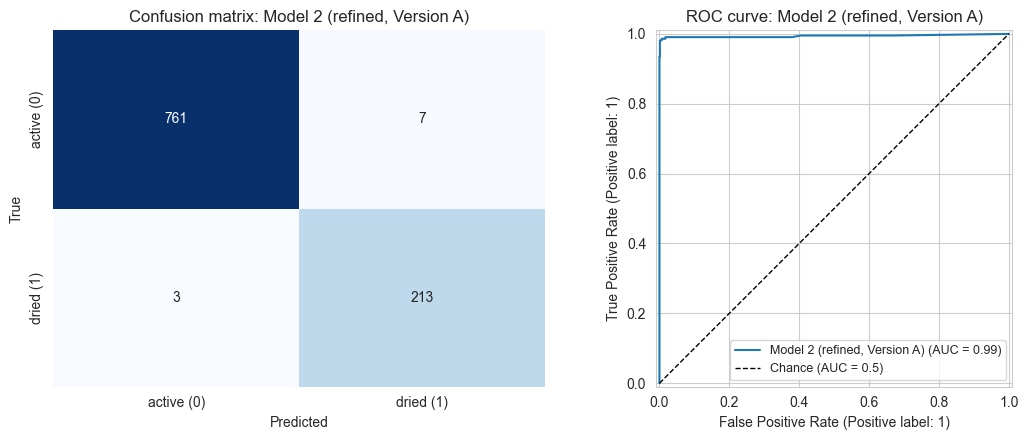

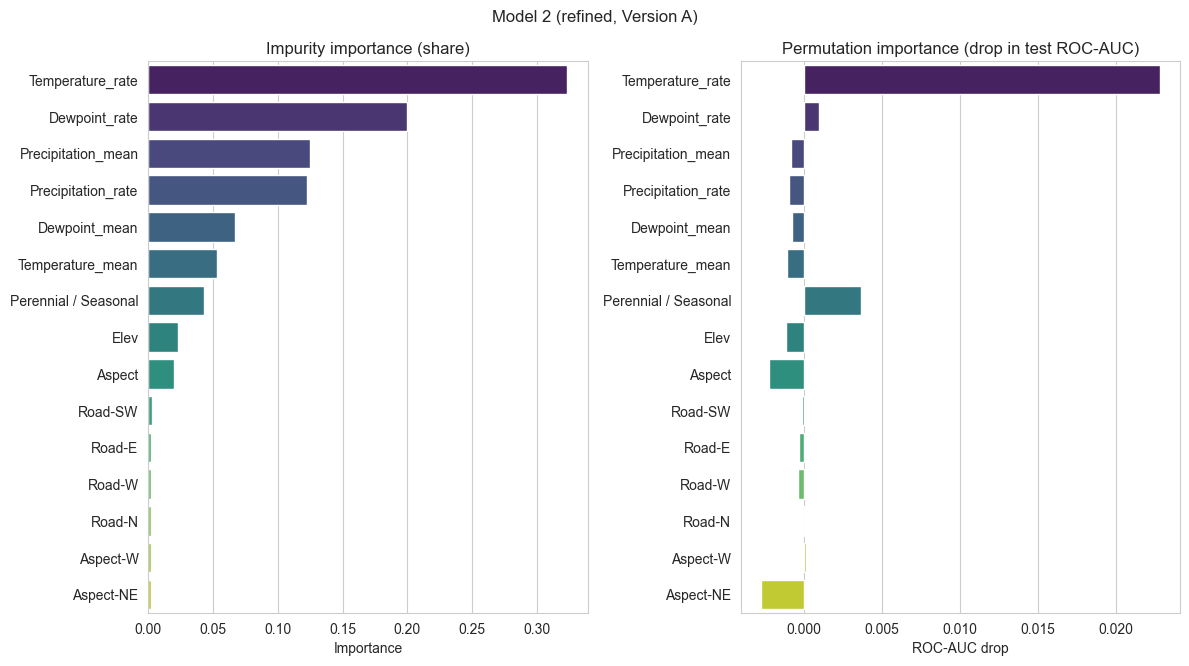

Model 2 (refined, Version A)  (n = 3278, dried = 718, test = 984)
  test: accuracy 0.990, precision 0.968, recall 0.986, f1 0.977, roc_auc 0.994
  confusion: TN 761  FP 7  FN 3  TP 213
  5-fold CV (shuffled): F1 0.983 +/- 0.004, AUC 0.994 +/- 0.004


In [2]:
version_a = pd.read_csv(TABLES_DIR / "climate_features_version_a.csv")
data = pd.concat([base.reset_index(drop=True), version_a], axis=1).rename(columns={"perennial": "Perennial / Seasonal"})
climate = [c for c in FEATURE_COLS if not c.startswith("Evaporation")]
features = ["Perennial / Seasonal", "Elev", "Aspect"] + ROADS + ASPECT_1HOT + climate
valid = data[features].notna().all(axis=1)
print(len(features), "features;", int(valid.sum()), "springs")
result, model = run_experiment("model2_refined", "Model 2 (refined, Version A)",
                               data.loc[valid, features], data.loc[valid, "dried"].values, make_rf())
print_result(result)